In [3]:
from google.colab import files
files.upload()

Saving Azure_Engineered_Features_2024.csv to Azure_Engineered_Features_2024.csv


{'Azure_Engineered_Features_2024.csv': b'Date_of_Usage,Demand_Units,Capacity_Allocated,Cost_USD,Service_Availability_Percent,Economic_Activity_Index,Year,Month,Utilization_Ratio,Dayofweek,Dayofyear,Weekofyear,Is_Weekend,Demand_Units_Lag_1,Demand_Units_Lag_7,Demand_Units_Lag_30,Demand_Change,Usage_Spike,Region_South India,Region_Southeast Asia,Region_West Europe,Service_Type_Storage\n2024-01-01,2098.0,2412.0,12588.0,99.902,101.75,2024,1,0.8698175787728026,0,1,1,False,,,,,False,False,False,False,False\n2024-01-02,2020.0,2323.0,12120.0,99.955,101.98,2024,1,0.8695652173913043,1,2,1,False,2098.0,,,-78.0,False,False,False,False,False\n2024-01-03,2107.0,2423.0,12642.0,99.987,101.49,2024,1,0.8695831613702022,2,3,1,False,2020.0,,,87.0,False,False,False,False,False\n2024-01-04,2013.0,2314.0,12078.0,99.9,100.71,2024,1,0.8699222126188418,3,4,1,False,2107.0,,,-94.0,False,False,False,False,False\n2024-01-05,2002.0,2302.0,12012.0,99.98,101.08,2024,1,0.8696785403996524,4,5,1,False,2013.0,,,-11.0,False

In [4]:
import pandas as pd

data = pd.read_csv("Azure_Engineered_Features_2024.csv")

print(data.head())

  Date_of_Usage  Demand_Units  Capacity_Allocated  Cost_USD  \
0    2024-01-01        2098.0              2412.0   12588.0   
1    2024-01-02        2020.0              2323.0   12120.0   
2    2024-01-03        2107.0              2423.0   12642.0   
3    2024-01-04        2013.0              2314.0   12078.0   
4    2024-01-05        2002.0              2302.0   12012.0   

   Service_Availability_Percent  Economic_Activity_Index  Year  Month  \
0                        99.902                   101.75  2024      1   
1                        99.955                   101.98  2024      1   
2                        99.987                   101.49  2024      1   
3                        99.900                   100.71  2024      1   
4                        99.980                   101.08  2024      1   

   Utilization_Ratio  Dayofweek  ...  Is_Weekend  Demand_Units_Lag_1  \
0           0.869818          0  ...       False                 NaN   
1           0.869565          1  ...  

In [5]:
import os
print(os.listdir())

['.config', 'Azure_Engineered_Features_2024.csv', 'sample_data']


In [6]:
pd.read_csv("Azure_Engineered_Features_2024.csv")

,Date_of_Usage,Demand_Units,Capacity_Allocated,Cost_USD,Service_Availability_Percent,Economic_Activity_Index,Year,Month,Utilization_Ratio,Dayofweek,...,Is_Weekend,Demand_Units_Lag_1,Demand_Units_Lag_7,Demand_Units_Lag_30,Demand_Change,Usage_Spike,Region_South India,Region_Southeast Asia,Region_West Europe,Service_Type_Storage
0,2024-01-01,2098.0,2412.0,12588.0,99.902,101.75,2024,1,0.869818,0,...,False,NaN,NaN,NaN,NaN,False,False,False,False,False
1,2024-01-02,2020.0,2323.0,12120.0,99.955,101.98,2024,1,0.869565,1,...,False,2098.0,NaN,NaN,-78.0,False,False,False,False,False
2,2024-01-03,2107.0,2423.0,12642.0,99.987,101.49,2024,1,0.869583,2,...,False,2020.0,NaN,NaN,87.0,False,False,False,False,False
3,2024-01-04,2013.0,2314.0,12078.0,99.900,100.71,2024,1,0.869922,3,...,False,2107.0,NaN,NaN,-94.0,False,False,False,False,False
4,2024-01-05,2002.0,2302.0,12012.0,99.980,101.08,2024,1,0.869679,4,...,False,2013.0,NaN,NaN,-11.0,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,2024-12-27,890.0,1023.0,4005.0,99.975,99.80,2024,12,0.869990,4,...,False,986.0,942.0,931.0,-96.0,False,False,False,True,True
2924,2024-12-28,990.0,1138.0,4455.0,99.900,100.25,2024,12,0.869947,5,...,True,890.0,940.0,882.5,100.0,False,False,False,True,True
2925,2024-12-29,970.0,1115.0,4365.0,99.971,99.68,2024,12,0.869955,6,...,True,990.0,911.0,834.0,-20.0,False,False,False,True,True
2926,2024-12-30,1016.0,1168.0,4572.0,99.936,99.82,2024,12,0.869863,0,...,False,970.0,929.0,943.0,46.0,False,False,False,True,True


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [9]:
data = pd.read_csv("Azure_Engineered_Features_2024.csv")

print(data.head())
print(data.info())

  Date_of_Usage  Demand_Units  Capacity_Allocated  Cost_USD  \
0    2024-01-01        2098.0              2412.0   12588.0   
1    2024-01-02        2020.0              2323.0   12120.0   
2    2024-01-03        2107.0              2423.0   12642.0   
3    2024-01-04        2013.0              2314.0   12078.0   
4    2024-01-05        2002.0              2302.0   12012.0   

   Service_Availability_Percent  Economic_Activity_Index  Year  Month  \
0                        99.902                   101.75  2024      1   
1                        99.955                   101.98  2024      1   
2                        99.987                   101.49  2024      1   
3                        99.900                   100.71  2024      1   
4                        99.980                   101.08  2024      1   

   Utilization_Ratio  Dayofweek  ...  Is_Weekend  Demand_Units_Lag_1  \
0           0.869818          0  ...       False                 NaN   
1           0.869565          1  ...  

In [10]:
data['Date_of_Usage'] = pd.to_datetime(data['Date_of_Usage'])

data = data.sort_values('Date_of_Usage')

In [12]:
X = data.drop(columns=["Demand_Units","Date_of_Usage"])
y = data["Demand_Units"]

In [13]:
split = int(len(data)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [14]:
def evaluate(y_true,y_pred):

    mae = mean_absolute_error(y_true,y_pred)

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))

    bias = np.mean(y_pred - y_true)

    return mae,rmse,bias

In [15]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb_model.fit(X_train,y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae,xgb_rmse,xgb_bias = evaluate(y_test,xgb_pred)

print("XGBoost Results")
print("MAE:",xgb_mae)
print("RMSE:",xgb_rmse)
print("Bias:",xgb_bias)

XGBoost Results
MAE: 1.7017932670515146
RMSE: 3.719996457139531
Bias: -0.3103562703311647


In [16]:
series = data["Demand_Units"]

train = series[:split]
test = series[split:]

arima = ARIMA(train,order=(5,1,0))

arima_model = arima.fit()

arima_pred = arima_model.forecast(steps=len(test))

arima_mae,arima_rmse,arima_bias = evaluate(test,arima_pred)

print("ARIMA Results")
print("MAE:",arima_mae)
print("RMSE:",arima_rmse)
print("Bias:",arima_bias)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


ARIMA Results
MAE: 405.15344853779385
RMSE: 526.5774618350529
Bias: -386.08319045447837


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [17]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(data[["Demand_Units"]])

X_lstm = []
y_lstm = []

window = 5

for i in range(window,len(scaled)):

    X_lstm.append(scaled[i-window:i])
    y_lstm.append(scaled[i])

X_lstm,y_lstm = np.array(X_lstm),np.array(y_lstm)

split = int(len(X_lstm)*0.8)

X_train = X_lstm[:split]
X_test = X_lstm[split:]

y_train = y_lstm[:split]
y_test = y_lstm[split:]

In [18]:
model = Sequential()

model.add(LSTM(50,input_shape=(X_train.shape[1],1)))

model.add(Dense(1))

model.compile(optimizer="adam",loss="mse")

model.fit(X_train,y_train,epochs=20,batch_size=16)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1202
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0747
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0714
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0731
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0705
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0706
Epoch 7/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0726
Epoch 8/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0723
Epoch 9/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0696
Epoch 10/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0709
Epoch 11/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0716
Epoch 12/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0727
Epoch 13/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0738
Epoch 14/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0728
Epoch 15/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0735


In [19]:
lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_inv = scaler.inverse_transform(y_test)

lstm_mae,lstm_rmse,lstm_bias = evaluate(y_test_inv,lstm_pred)

print("LSTM Results")
print("MAE:",lstm_mae)
print("RMSE:",lstm_rmse)
print("Bias:",lstm_bias)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
LSTM Results
MAE: 375.1894262069311
RMSE: 404.59768487433524
Bias: 28.03216792701656


In [20]:
results = pd.DataFrame({

"Model":["ARIMA","XGBoost","LSTM"],

"MAE":[arima_mae,xgb_mae,lstm_mae],

"RMSE":[arima_rmse,xgb_rmse,lstm_rmse],

"Bias":[arima_bias,xgb_bias,lstm_bias]

})

print(results)

     Model         MAE        RMSE        Bias
0    ARIMA  405.153449  526.577462 -386.083190
1  XGBoost    1.701793    3.719996   -0.310356
2     LSTM  375.189426  404.597685   28.032168


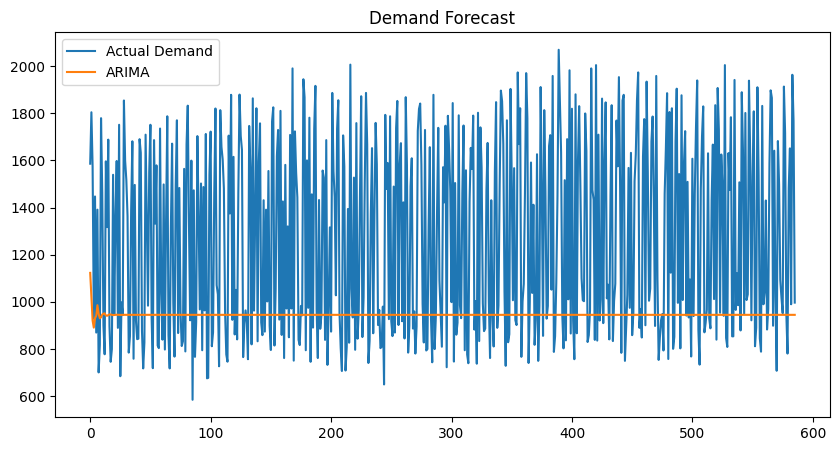

In [21]:
plt.figure(figsize=(10,5))

plt.plot(test.values,label="Actual Demand")

plt.plot(arima_pred.values,label="ARIMA")

plt.legend()

plt.title("Demand Forecast")

plt.show()